# LookingGlass: Generative Anamorphoses via Laplacian Pyramid Warping

This notebook implements the method from `../LookingGlass.pdf` and uses `../VisualAnagramCode.ipynb` as the comparison baseline. Generated files are written into this `LookingGlass` folder.

The default path follows the paper: Stable Diffusion 3.5 Medium, FlowMatch clean-latent synchronization, image-space Laplacian Pyramid Warping, VAE re-encoding, and latent residual correction.

## What changes from Visual Anagrams?

| Part | Visual Anagrams notebook | LookingGlass notebook |
|---|---|---|
| Model | DeepFloyd IF pixel diffusion + x4 upscaler | Stable Diffusion 3/3.5 latent rectified flow |
| Synchronized value | Noisy samples/noise predictions | Predicted clean latents (`latent - sigma * velocity`) |
| Transform support | Mostly orthogonal/noise-preserving transforms | General UV maps, including mirror/lens-style warps |
| Warp space | Pixel diffusion space | Decode to image space, warp, re-encode |
| Blend | Direct averaging | Laplacian Pyramid Warping with masked/value-weighted blending |
| VAE issue | Not applicable in DeepFloyd stage I/II | Residual correction for VAE round-trip loss |

The important implementation detail is that arbitrary warps should not be applied directly to Gaussian noise or raw VAE latents. LookingGlass moves the geometric work into image space, then returns to latent space for the model step.

## 1. Install dependencies in Google Colab

Colab already ships with PyTorch and a large Google client-library stack. The important thing is to avoid unconstrained upgrades that pull in `protobuf` 6/7 or prerelease `safetensors` builds. Run this cell once, then restart the runtime when Colab asks.

In [1]:
# Colab-safe install. Do not reinstall torch unless Colab's built-in torch is missing.
# The protobuf constraint is intentional: Colab's Google packages currently need protobuf < 6.
%pip install -q --upgrade --upgrade-strategy only-if-needed \
  "diffusers==0.37.1" \
  "transformers==4.57.6" \
  "accelerate>=1.10,<2" \
  "huggingface_hub>=0.36,<1" \
  "safetensors>=0.6.2,<0.8" \
  "protobuf>=5.29.1,<6" \
  "mediapy>=1.2" \
  "scipy>=1.11"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.4 MB/s eta 0:00:00


## If you already installed the conflicting packages

If you ran the older loose install cell, the safest fix in Colab is **Runtime -> Disconnect and delete runtime**, then reopen the notebook and run the updated setup cell. The old cell could alter both `protobuf` and the PyTorch/torchvision stack.

If you do not want to reset the VM, rerun the setup cell above to downgrade `protobuf` from 7.x to a Colab-compatible 5.29.x release and move `transformers` back to the latest 4.x line. Then use **Runtime -> Restart runtime** before importing `diffusers`, `transformers`, or any `google.*` packages.

## 2. Hugging Face access

`stabilityai/stable-diffusion-3.5-medium` is a gated Hugging Face model. Before loading it, do both of these:

1. Open https://huggingface.co/stabilityai/stable-diffusion-3.5-medium and accept the license/access terms while logged into Hugging Face.
2. Use a Hugging Face token from https://huggingface.co/settings/tokens with read access. The next cell will use an existing Hugging Face login token if one is already available; otherwise it will open the standard Hugging Face login prompt.

After login, the notebook stores the token only in the runtime variable `HF_TOKEN` so the model-loading cell can access the gated checkpoint.

In [3]:
from huggingface_hub import get_token, hf_hub_download, login
from huggingface_hub.utils import GatedRepoError, HfHubHTTPError

HF_MODEL_ID = "stabilityai/stable-diffusion-3.5-medium"
HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if HF_TOKEN:
    login(token=HF_TOKEN)
else:
    login()
    HF_TOKEN = get_token()

try:
    hf_hub_download(HF_MODEL_ID, "model_index.json", token=HF_TOKEN)
    print(f"Access check passed for {HF_MODEL_ID}.")
except GatedRepoError as exc:
    raise RuntimeError(
        "Hugging Face rejected access to the gated SD3.5 Medium repo. "
        "Open https://huggingface.co/stabilityai/stable-diffusion-3.5-medium, "
        "accept the license/access terms with the same account that owns your token, "
        "then rerun this cell."
    ) from exc
except HfHubHTTPError as exc:
    raise RuntimeError(
        "Hugging Face authentication failed. Check that your active token exists "
        "and has read access to the gated model."
    ) from exc


model_index.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

Access check passed for stabilityai/stable-diffusion-3.5-medium.


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 3. Imports

In [5]:
from pathlib import Path
import importlib
import sys

DRIVE_ROOT = Path("/content/drive/MyDrive/NimaK/LookingGlass")
candidates = [
    Path.cwd(),
    Path.cwd() / "LookingGlass",
    DRIVE_ROOT,
]
for candidate in candidates:
    if (candidate / "lookingglass_utils.py").exists():
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not find lookingglass_utils.py")

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import torch
import mediapy as mp
from PIL import Image

import time_travel
import lookingglass_utils
importlib.reload(time_travel)
importlib.reload(lookingglass_utils)

from lookingglass_utils import (
    ViewSpec,
    FactorizedViewSpec,
    forward_lpw,
    load_sd3_pipeline,
    make_conic_mirror_uv,
    make_cylindrical_mirror_uv,
    make_oblique_cylindrical_mirror_uv,
    make_faceted_lens_uv,
    make_flip_uv,
    make_identity_uv,
    make_inner_rotate_uv,
    make_rotate_uv,
    sample_lookingglass,
    sample_factorized_lookingglass,
    sample_figure5_ablation,
    sample_figure5_lpw_ablation,
)
from time_travel import (
    flowmatch_euler_step,
    time_travel_transitions,
    validate_time_travel_velocity_mode,
)

print("Notebook dir:", NOTEBOOK_DIR)
print("CUDA available:", torch.cuda.is_available())
print("Time-travel modes:", [validate_time_travel_velocity_mode(m) for m in ["sync", "noise", "unsync", "full_sync", "full_unsync", "new_full_sync", "weighted_noise_unsync"]])
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Notebook dir: /content/drive/MyDrive/NimaK/LookingGlass
CUDA available: True
Time-travel modes: ['sync', 'noise', 'unsync', 'full_sync', 'full_unsync', 'new_full_sync', 'weighted_noise_unsync']
GPU: NVIDIA A100-SXM4-80GB


## 4. Model choice

This notebook now uses the full paper-style configuration by default: Stable Diffusion 3.5 Medium, full SD3 text encoders including T5-XXL, 1024 resolution, 30 inference steps, LPW nearest sampling, and paper-style one-step time travel between 20% and 80% of the sampling trajectory.

The Flax deprecation messages sometimes printed by Diffusers are harmless here; this notebook uses the PyTorch `StableDiffusion3Pipeline`. The actual blocker to watch for is gated-model authentication.

In [6]:
MODEL_ID = HF_MODEL_ID
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Full paper-style mode: load the complete SD3.5 pipeline, including T5-XXL.
pipe = load_sd3_pipeline(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
    device=DEVICE,
    cpu_offload=False,
    token=HF_TOKEN,
)

print("Full LookingGlass mode: full SD3.5 pipeline on device, T5 loaded, resolution=1024x1024, steps=30")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Full LookingGlass mode: full SD3.5 pipeline on device, T5 loaded, resolution=1024x1024, steps=30


## 5. Choose prompts and view

`VIEW_KIND` can be `flip`, `rotate_90`, `inner_rotate_135`, `conic`, `cylindrical`, or `lens`.

For the cylinder setup, this notebook uses a **top-mounted oblique cylinder**: the cylinder center is near the top of the generated picture, the radius is `1/8` of the side length, and the view ray is 60 degrees from the vertical cylinder axis. That better matches a Blender camera looking at the plane and mirror from an angle.

For a fully paper-exact physical setup, replace the procedural UV with a ray-traced UV generated from the exact Blender/camera/cylinder geometry.

In [7]:
HEIGHT = 1024
WIDTH = 1024
VIEW_KIND = "flip"  # flip, rotate_90, inner_rotate_135, conic, cylindrical, lens

STYLE = "a sketch of"
PROMPT_IDENTITY = "a giraffe head"
PROMPT_HIDDEN = "a penguin"

# Top-mounted oblique cylinder parameters in normalized image coordinates.
# Image UV convention: u=0 left, u=1 right, v=0 top, v=1 bottom.
# Blender convention assumed below: image plane is centered at origin and top of image points to +Y.
CYLINDER_CENTER_UV = (0.5, 0.17)
CYLINDER_RADIUS_UV = 0.125          # 1/8 of the picture side length
CYLINDER_MIRROR_HEIGHT_UV = 0.30    # cylinder height in picture-side units, used by the ray-traced UV
CYLINDER_MIRROR_Z_MIN_UV = 0.02     # avoids sampling exactly at the contact line
CYLINDER_VIEW_ANGLE_DEGREES = 60.0  # angle between cylinder axis and view vector
CYLINDER_VIEW_AZIMUTH_DEGREES = 90.0  # camera below image, looking toward +Y/top of picture
CYLINDER_VISIBLE_ARC_DEGREES = 130.0

uv_identity = make_identity_uv(HEIGHT, WIDTH)

if VIEW_KIND == "flip":
    uv_hidden = make_flip_uv(HEIGHT, WIDTH, axis="vertical")
elif VIEW_KIND == "rotate_90":
    uv_hidden = make_rotate_uv(HEIGHT, WIDTH, angle_degrees=90)
elif VIEW_KIND == "inner_rotate_135":
    uv_hidden = make_inner_rotate_uv(HEIGHT, WIDTH, angle_degrees=135, radius=0.42)
elif VIEW_KIND == "conic":
    uv_hidden = make_conic_mirror_uv(HEIGHT, WIDTH, ring_inner=0.18, ring_outer=0.49)
elif VIEW_KIND == "cylindrical":
    uv_hidden = make_oblique_cylindrical_mirror_uv(
        HEIGHT,
        WIDTH,
        center=CYLINDER_CENTER_UV,
        radius=CYLINDER_RADIUS_UV,
        mirror_height=CYLINDER_MIRROR_HEIGHT_UV,
        mirror_z_min=CYLINDER_MIRROR_Z_MIN_UV,
        view_angle_degrees=CYLINDER_VIEW_ANGLE_DEGREES,
        view_azimuth_degrees=CYLINDER_VIEW_AZIMUTH_DEGREES,
        visible_arc_degrees=CYLINDER_VISIBLE_ARC_DEGREES,
    )
elif VIEW_KIND == "lens":
    uv_hidden = make_faceted_lens_uv(HEIGHT, WIDTH, facets=9, strength=0.12)
else:
    raise ValueError(f"Unknown VIEW_KIND: {VIEW_KIND}")

views = [
    ViewSpec("identity", f"{STYLE} {PROMPT_IDENTITY}", uv_identity),
    ViewSpec(VIEW_KIND, f"{STYLE} {PROMPT_HIDDEN}", uv_hidden),
]

for view in views:
    print(f"{view.name}: {view.prompt}")
print(f"resolution: {HEIGHT} x {WIDTH}")
if VIEW_KIND == "cylindrical":
    print("Blender placement for plane side length L:")
    print(f"  cylinder center UV = {CYLINDER_CENTER_UV}")
    print(f"  cylinder radius    = {CYLINDER_RADIUS_UV} * L")
    print(f"  cylinder height    = {CYLINDER_MIRROR_HEIGHT_UV} * L")
    print(f"  camera angle       = {CYLINDER_VIEW_ANGLE_DEGREES} degrees from cylinder axis")
    print("  if top of the image is +Y in Blender: location = (0, (0.5 - center_v) * L, height/2)")

identity: a sketch of a giraffe head
flip: a sketch of a penguin
resolution: 1024 x 1024


### Using ray-traced UV maps

In [ ]:
# Optional: load Blender ray-traced UV map and replace the procedural hidden view.
# Prefer the cropped cylinder-only export. The full-camera export is only a fallback/debug map.
# Run export_cropped_cylinder_uv.py in Blender first, then set USE_RAYTRACED_UV = True.
USE_RAYTRACED_UV = True
RAYTRACED_VIEW_NAME = "cylinder_raytraced"

RAYTRACED_UV_CANDIDATES = [
    NOTEBOOK_DIR / "Results" / "lookingglass_uv" / "cylinder_raytraced_uv_cropped.npy",
    NOTEBOOK_DIR / "lookingglass_uv" / "cylinder_raytraced_uv_cropped.npy",
    NOTEBOOK_DIR / "cylinder_raytraced_uv_cropped.npy",
    NOTEBOOK_DIR / "Results" / "lookingglass_uv" / "cylinder_raytraced_uv.npy",
    NOTEBOOK_DIR / "lookingglass_uv" / "cylinder_raytraced_uv.npy",
    NOTEBOOK_DIR / "cylinder_raytraced_uv.npy",
]

if USE_RAYTRACED_UV:
    raytraced_uv_path = next((path for path in RAYTRACED_UV_CANDIDATES if path.exists()), None)
    if raytraced_uv_path is None:
        searched = "\n".join(f"  - {path}" for path in RAYTRACED_UV_CANDIDATES)
        raise FileNotFoundError(
            "Ray-traced UV map was not found. Export it from Blender first, or set "
            "USE_RAYTRACED_UV = False to keep the procedural UV.\nSearched:\n"
            f"{searched}"
        )

    uv_np = np.load(raytraced_uv_path)
    if uv_np.ndim != 3 or uv_np.shape[-1] != 2:
        raise ValueError(f"Expected UV shape [H, W, 2], got {uv_np.shape} from {raytraced_uv_path}")
    if uv_np.shape[:2] != (HEIGHT, WIDTH):
        raise ValueError(
            f"Ray-traced UV shape {uv_np.shape[:2]} does not match notebook resolution "
            f"{(HEIGHT, WIDTH)}. Re-export from Blender with OUT_RES_X={WIDTH}, OUT_RES_Y={HEIGHT}."
        )

    uv_hidden = torch.from_numpy(uv_np).to(dtype=torch.float32)
    uv_hidden[~torch.isfinite(uv_hidden).all(dim=-1)] = float("nan")
    raytraced_view_name = (
        "cylinder_raytraced_cropped" if "cropped" in raytraced_uv_path.stem else RAYTRACED_VIEW_NAME
    )
    views = [
        ViewSpec("identity", f"{STYLE} {PROMPT_IDENTITY}", uv_identity),
        ViewSpec(raytraced_view_name, f"{STYLE} {PROMPT_HIDDEN}", uv_hidden),
    ]

    valid_pixels = torch.isfinite(uv_hidden).all(dim=-1).sum().item()
    total_pixels = uv_hidden.shape[0] * uv_hidden.shape[1]
    print(f"Loaded ray-traced UV map: {raytraced_uv_path}")
    print(f"view name: {raytraced_view_name}")
    print(f"valid mirror pixels: {valid_pixels:,} / {total_pixels:,} ({valid_pixels / total_pixels:.2%})")
    print("Later preview/generation cells will use the ray-traced hidden view.")


Loaded ray-traced UV map: /content/drive/MyDrive/NimaK/LookingGlass/Results/lookingglass_uv/cylinder_raytraced_uv_cropped.npy
view name: cylinder_raytraced_cropped
valid mirror pixels: 605,780 / 1,048,576 (57.77%)
Later preview/generation cells will use the ray-traced hidden view.


In [ ]:
# --- Factorized LookingGlass views ---
# Identity is a hybrid: low freq = village, high freq = turtle.
# Mirror is single-prompt: just an old man.

FACTORIZED_STYLE = "a watercolor painting of"
FACTORIZED_IDENTITY_LOW = "a snow mountain village"
FACTORIZED_IDENTITY_HIGH = "a face"
FACTORIZED_HIDDEN = "an old man"
BLUR_SIGMA = 10.0

factorized_views = [
    FactorizedViewSpec(
        name="identity",
        prompts=[f"{FACTORIZED_STYLE} {FACTORIZED_IDENTITY_LOW}",
                 f"{FACTORIZED_STYLE} {FACTORIZED_IDENTITY_HIGH}"],
        uv=uv_identity,
        blur_sigma=BLUR_SIGMA,
    ),
    FactorizedViewSpec(
        name=VIEW_KIND,
        prompts=[f"{FACTORIZED_STYLE} {FACTORIZED_HIDDEN}"],
        uv=uv_hidden,
        blur_sigma=BLUR_SIGMA,
    ),
]

for v in factorized_views:
    print(f"{v.name}: {v.prompts}")

identity: ['a watercolor painting of a snow mountain village', 'a watercolor painting of a face']
inner_rotate_135: ['a watercolor painting of an old man']


## 6. Preview the UV maps

Red is canonical `u`, green is canonical `v`, and blue marks valid pixels. Black/low-blue regions are undefined and are ignored in inverse LPW.

identity,flip

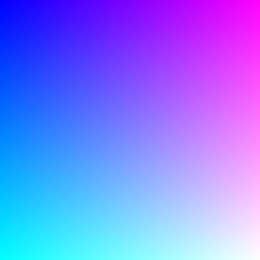
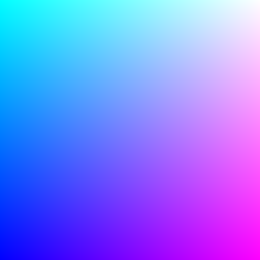

In [8]:
def uv_to_preview(uv):
    if uv.ndim == 4:
        uv = uv[0]
    arr = uv.detach().cpu().numpy()
    valid = np.isfinite(arr).all(axis=-1)
    rgb = np.zeros((*arr.shape[:2], 3), dtype=np.float32)
    rgb[..., 0] = np.nan_to_num(arr[..., 0], nan=0.0)
    rgb[..., 1] = np.nan_to_num(arr[..., 1], nan=0.0)
    rgb[..., 2] = valid.astype(np.float32)
    return (np.clip(rgb, 0, 1) * 255).astype(np.uint8)

mp.show_images([uv_to_preview(view.uv) for view in views], titles=[view.name for view in views], width=260)

## 7. Generate

These defaults match the paper-style recipe: 30 steps, LPW nearest sampling, value-weighted Laplacian blending, five synchronization repeats between 20% and 80% of the trajectory, and identity-view prioritization during the final 20% of steps.

#### Define saving function

In [9]:
import json
import datetime
import torch
from PIL.PngImagePlugin import PngInfo
from torchvision.transforms.functional import pil_to_tensor, to_pil_image

def save_lookingglass_results(
    output_dir,
    views,
    images,
    uv_hidden,
    device,
    view_kind,
    style,
    prompt_identity,
    prompt_hidden,
    seed,
    num_inference_steps,
    guidance_scale,
    image_levels,
    latent_levels,
    sync_repeats,
    lpw_sample_mode,
    alpha,
    prioritize_view,
    prioritize_fraction,
    time_travel_mode,
    basename_params=None,
):
    out_folder = output_dir / str(view_kind)
    out_folder.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    params = {
        "SEED": seed,
        "VIEW_KIND": view_kind,
        "STYLE": style,
        "PROMPT_IDENTITY": prompt_identity,
        "PROMPT_HIDDEN": prompt_hidden,
        "NUM_INFERENCE_STEPS": num_inference_steps,
        "GUIDANCE_SCALE": guidance_scale,
        "IMAGE_LEVELS": image_levels,
        "LATENT_LEVELS": latent_levels,
        "SYNC_REPEATS": sync_repeats,
        "LPW_SAMPLE_MODE": lpw_sample_mode,
        "ALPHA": alpha,
        "PRIORITIZE_VIEW": prioritize_view,
        "PRIORITIZE_FRACTION": prioritize_fraction,
        "TIME_TRAVEL_MODE": time_travel_mode,
    }

    if basename_params is None:
        basename_params = ["STYLE", "PROMPT_IDENTITY", "PROMPT_HIDDEN"]

    name_parts = []
    for p in basename_params:
        if p in params:
            val = str(params[p]).strip().replace(" ", "_")
            name_parts.append(val)

    name_parts.append(timestamp)
    base_name = "_".join(name_parts)

    metadata = PngInfo()
    metadata.add_text("parameters", json.dumps(params, indent=4))

    for view, image in zip(views, images):
        path = out_folder / f"{base_name}_{view.name}.png"
        image.save(path, pnginfo=metadata)
        print("saved", path)

    ## Render and save the hidden view
    #identity_tensor = pil_to_tensor(images[0]).float().unsqueeze(0) / 255.0
    #identity_tensor = identity_tensor * 2.0 - 1.0
    #with torch.no_grad():
    #    rendered = forward_lpw(
    #        identity_tensor.to(device),
    #        uv_hidden.to(device),
    #        levels=image_levels,
    #        fill_value=0.0,
    #        sample_mode=lpw_sample_mode,
    #    )
    #rendered = ((rendered[0].detach().cpu().clamp(-1, 1) + 1.0) / 2.0)
    #rendered_pil = to_pil_image(rendered)
    #render_path = out_folder / f"{base_name}_rendered_hidden_view.png"
    #rendered_pil.save(render_path, pnginfo=metadata)
    #print("saved", render_path)


### Generate

identity,flip

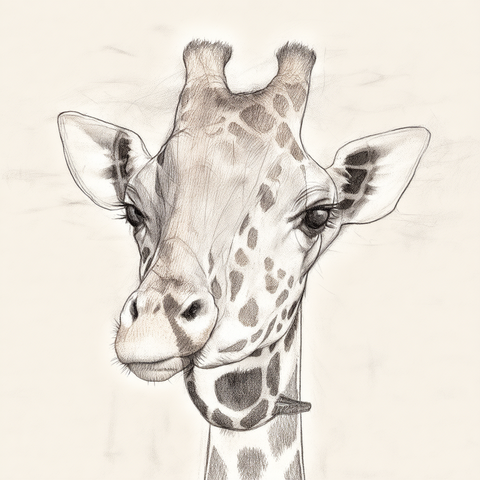
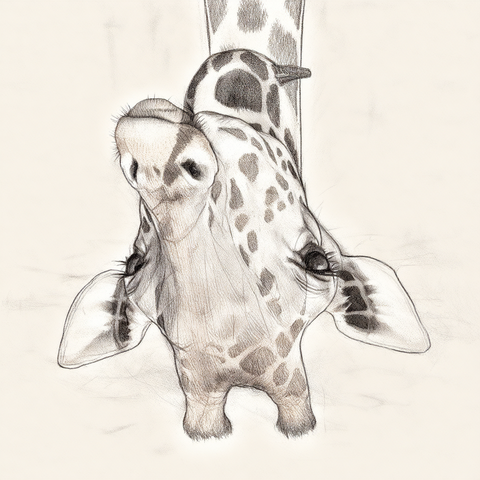

saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_1_20260604_190338_identity.png
saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_1_20260604_190338_flip.png


identity,flip

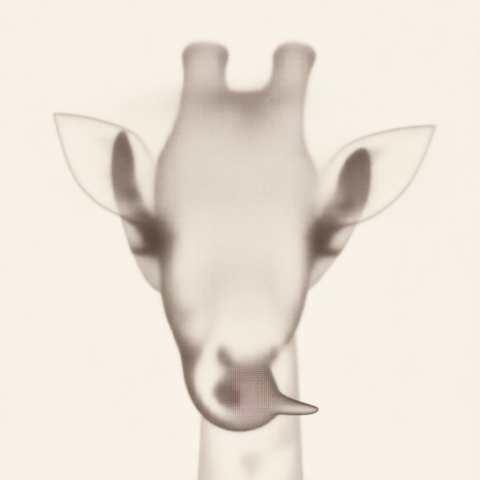
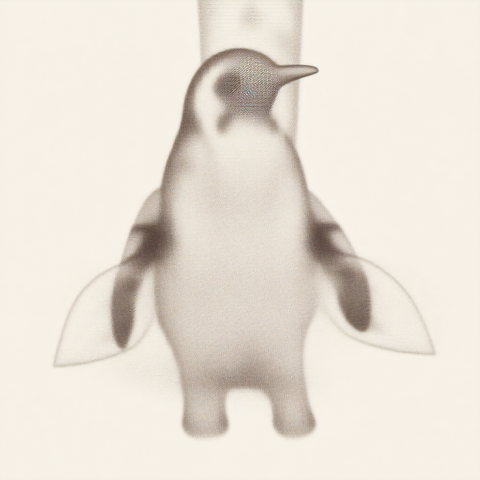

saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_2_20260604_190452_identity.png
saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_2_20260604_190452_flip.png


identity,flip

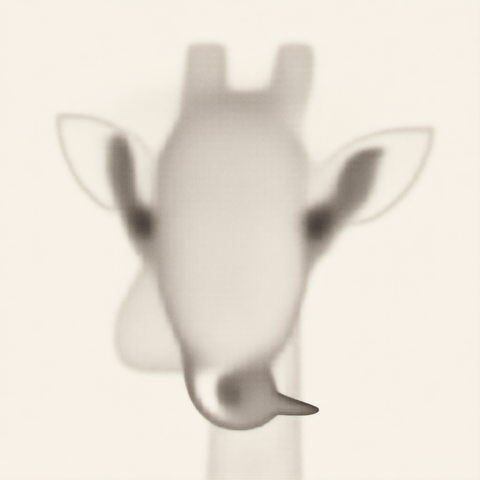
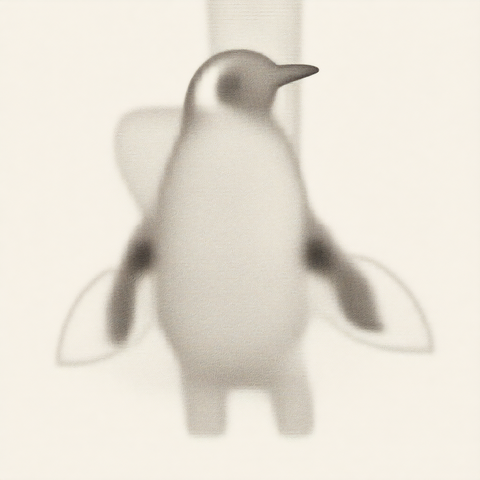

saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_3_20260604_190645_identity.png
saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_3_20260604_190645_flip.png


identity,flip

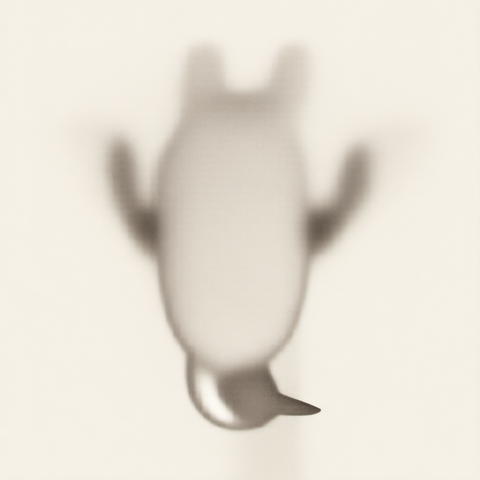
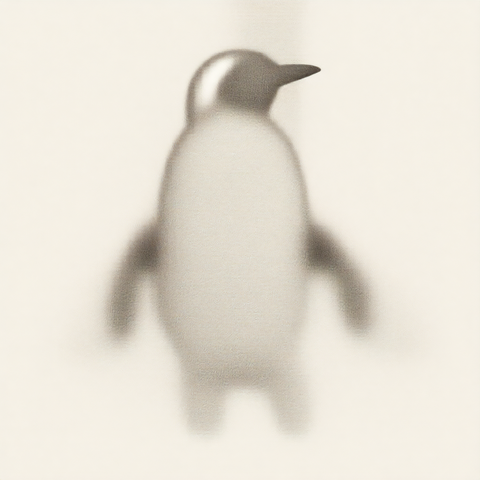

saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_4_20260604_190917_identity.png
saved /content/drive/MyDrive/NimaK/LookingGlass/flip/1_new_full_sync_4_20260604_190917_flip.png


In [ ]:
SEED = 1
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 4.5
IMAGE_LEVELS = 6
LATENT_LEVELS = 4
SYNC_REPEATS = [1,2,3,4,5,8]
ALPHA = 0.75
PRIORITIZE_VIEW = 0
PRIORITIZE_FRACTION = 0.20
LPW_SAMPLE_MODE = "nearest"
TIME_TRAVEL_MODES = ["new_full_sync"]


for mode in TIME_TRAVEL_MODES:
    for sync_repeats in SYNC_REPEATS:
        result = sample_lookingglass(
            pipe,
            views,
            height=HEIGHT,
            width=WIDTH,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            image_levels=IMAGE_LEVELS,
            latent_levels=LATENT_LEVELS,
            alpha=ALPHA,
            lpw_sample_mode=LPW_SAMPLE_MODE,
            seed=SEED,
            sync_repeat_start=0.20,
            sync_repeat_stop=0.80,
            sync_repeats=sync_repeats,
            prioritize_view=PRIORITIZE_VIEW,
            prioritize_fraction=PRIORITIZE_FRACTION,
            time_travel_velocity_mode=mode,
        )
        images = result["images"]
        mp.show_images(images, titles=[view.name for view in views], width=480)

        save_lookingglass_results(
            output_dir=NOTEBOOK_DIR,
            views=views,
            images=images,
            uv_hidden=uv_hidden,
            device=DEVICE,
            view_kind=VIEW_KIND,
            style=STYLE,
            prompt_identity=PROMPT_IDENTITY,
            prompt_hidden=PROMPT_HIDDEN,
            seed=SEED,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            image_levels=IMAGE_LEVELS,
            latent_levels=LATENT_LEVELS,
            sync_repeats=sync_repeats,
            lpw_sample_mode=LPW_SAMPLE_MODE,
            alpha=ALPHA,
            prioritize_view=PRIORITIZE_VIEW,
            prioritize_fraction=PRIORITIZE_FRACTION,
            time_travel_mode=mode,
            basename_params=["SEED", "TIME_TRAVEL_MODE", "SYNC_REPEATS"],
        )


## 8. Save outputs and render the hidden view from the identity image

The generated view images are decoded directly from their synchronized view latents. The extra render below applies the hidden UV map to the identity image so you can inspect what the mirror/lens transform reveals from the final canonical image.

saved /content/drive/MyDrive/NimaK/LookingGlass/flip/a_sketch_of_a_giraffe_head_a_penguin_20260602_094408_identity.png
saved /content/drive/MyDrive/NimaK/LookingGlass/flip/a_sketch_of_a_giraffe_head_a_penguin_20260602_094408_flip.png
saved /content/drive/MyDrive/NimaK/LookingGlass/flip/a_sketch_of_a_giraffe_head_a_penguin_20260602_094408_rendered_hidden_view.png


identity,flip

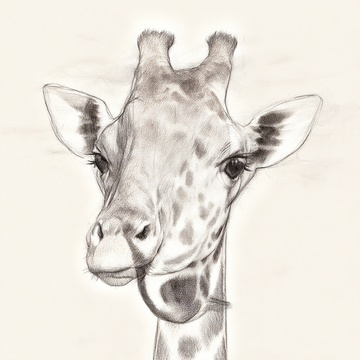
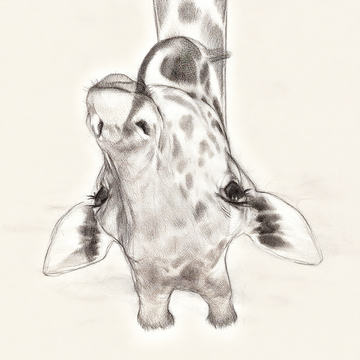

In [ ]:
output_dir = NOTEBOOK_DIR
out_folder = output_dir / str(VIEW_KIND)
out_folder.mkdir(parents=True, exist_ok=True)



#mp.show_images([images[0], rendered_pil, images[1]], titles=["identity", "rendered hidden view", views[1].name], width=360)
mp.show_images([images[0], images[1]], titles=["identity", views[1].name], width=360)

## 9. Using a custom ray-traced UV map

A UV map should have shape `[H, W, 2]`, where each target-view pixel stores the canonical coordinate `(u, v)` in normalized `[0, 1]` coordinates. Use `NaN` where the mirror or lens does not see the image plane.

For the cylindrical mirror, use the **cropped cylinder-only** Blender export, not the full camera frame. The hidden view for generation is the mirror surface itself; if the whole camera frame is used, the cylinder may occupy only a few percent of the UV image and the hidden prompt becomes weak/blurry.

Run `export_cropped_cylinder_uv.py` inside Blender. The notebook loader above searches for:

```text
Results/lookingglass_uv/cylinder_raytraced_uv_cropped.npy
lookingglass_uv/cylinder_raytraced_uv_cropped.npy
cylinder_raytraced_uv_cropped.npy
```

Manual replacement still looks like this:

```python
uv_hidden = torch.from_numpy(np.load(NOTEBOOK_DIR / "lookingglass_uv/cylinder_raytraced_uv_cropped.npy")).float()
views[1] = ViewSpec("cylinder_raytraced_cropped", f"{STYLE} {PROMPT_HIDDEN}", uv_hidden)
```


## 10. Figure 5 LPW Ablation: Contributions of Each Technique

This custom ablation keeps Laplacian Pyramid Warping active in every variant and removes the Geng/noisy-latent baseline. It uses the same 135-degree inner-rotation view and seed while comparing:

- `Final Estimate + LPW`: synchronize the predicted clean latent estimate with latent-space LPW.
- `+ VAE + LPW`: decode clean latents, synchronize in image space with LPW, then re-encode.
- `+ Residual Corr. + LPW`: add the latent VAE round-trip residual correction.

This block exposes the same sampler controls as full generation: LPW levels/alpha, paper-style one-step time-travel repeats, final-view prioritization, guidance scale, step count, seed, and max prompt length.


Final Estimate + LPW: identity,Final Estimate + LPW: inner_rotate_135
+ VAE + LPW: identity,+ VAE + LPW: inner_rotate_135
+ Residual Corr. + LPW: identity,+ Residual Corr. + LPW: inner_rotate_135

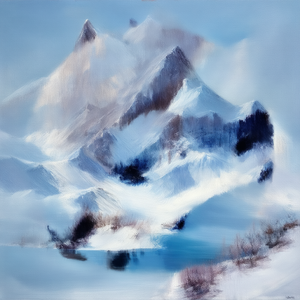
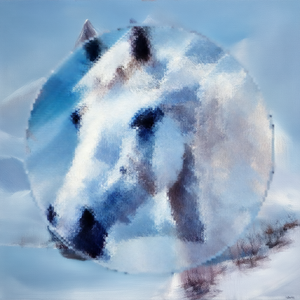
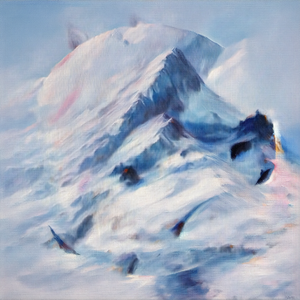
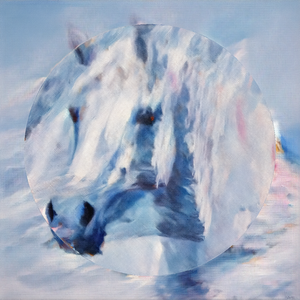
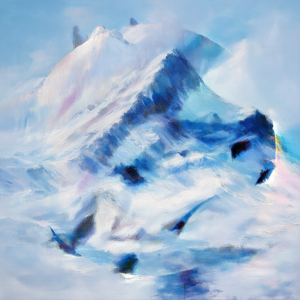
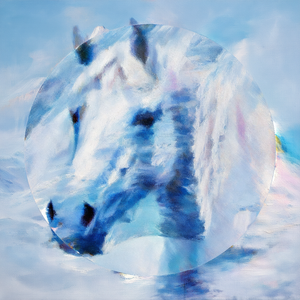

saved /content/drive/MyDrive/NimaK/LookingGlass/figure5_lpw_ablation/figure5_lpw_final_estimate_plus_lpw_identity_seed65535.png
saved /content/drive/MyDrive/NimaK/LookingGlass/figure5_lpw_ablation/figure5_lpw_final_estimate_plus_lpw_inner_rotate_135_seed65535.png
saved /content/drive/MyDrive/NimaK/LookingGlass/figure5_lpw_ablation/figure5_lpw_plus_vae_plus_lpw_identity_seed65535.png
saved /content/drive/MyDrive/NimaK/LookingGlass/figure5_lpw_ablation/figure5_lpw_plus_vae_plus_lpw_inner_rotate_135_seed65535.png
saved /content/drive/MyDrive/NimaK/LookingGlass/figure5_lpw_ablation/figure5_lpw_plus_residual_corr_plus_lpw_identity_seed65535.png
saved /content/drive/MyDrive/NimaK/LookingGlass/figure5_lpw_ablation/figure5_lpw_plus_residual_corr_plus_lpw_inner_rotate_135_seed65535.png


In [ ]:
FIG5_HEIGHT = 1024
FIG5_WIDTH = 1024
FIG5_SEED = 65535
FIG5_ANGLE = 135.0
FIG5_RADIUS = 0.42
FIG5_STYLE = "a painting of"
FIG5_PROMPT_1 = "a snow mountain"
FIG5_PROMPT_2 = "a horse"
FIG5_NUM_INFERENCE_STEPS = 30
FIG5_GUIDANCE_SCALE = 4.5

# LPW sharpness/detail controls for this ablation.
FIG5_IMAGE_LEVELS = 6
FIG5_LATENT_LEVELS = 4
FIG5_ALPHA = 0.9
FIG5_LPW_SAMPLE_MODE = "nearest"
FIG5_SYNC_REPEAT_START = 0.20
FIG5_SYNC_REPEAT_STOP = 0.80
FIG5_SYNC_REPEATS = 5
FIG5_PRIORITIZE_VIEW = 0
FIG5_PRIORITIZE_FRACTION = 0.20
FIG5_MAX_SEQUENCE_LENGTH = 256
FIG5_CORRELATED_INITIAL_NOISE = False

fig5_identity_uv = make_identity_uv(FIG5_HEIGHT, FIG5_WIDTH)
fig5_rotate_uv = make_inner_rotate_uv(
    FIG5_HEIGHT,
    FIG5_WIDTH,
    angle_degrees=FIG5_ANGLE,
    radius=FIG5_RADIUS,
)

fig5_views = [
    ViewSpec("identity", f"{FIG5_STYLE} {FIG5_PROMPT_1}", fig5_identity_uv),
    ViewSpec("inner_rotate_135", f"{FIG5_STYLE} {FIG5_PROMPT_2}", fig5_rotate_uv),
]

if torch.cuda.is_available():
    torch.cuda.empty_cache()

fig5_outputs = sample_figure5_lpw_ablation(
    pipe,
    fig5_views,
    height=FIG5_HEIGHT,
    width=FIG5_WIDTH,
    num_inference_steps=FIG5_NUM_INFERENCE_STEPS,
    guidance_scale=FIG5_GUIDANCE_SCALE,
    image_levels=FIG5_IMAGE_LEVELS,
    latent_levels=FIG5_LATENT_LEVELS,
    alpha=FIG5_ALPHA,
    seed=FIG5_SEED,
    lpw_sample_mode=FIG5_LPW_SAMPLE_MODE,
    sync_repeat_start=FIG5_SYNC_REPEAT_START,
    sync_repeat_stop=FIG5_SYNC_REPEAT_STOP,
    sync_repeats=FIG5_SYNC_REPEATS,
    prioritize_view=FIG5_PRIORITIZE_VIEW,
    prioritize_fraction=FIG5_PRIORITIZE_FRACTION,
    max_sequence_length=FIG5_MAX_SEQUENCE_LENGTH,
    correlated_initial_noise=FIG5_CORRELATED_INITIAL_NOISE,
)

fig5_images = []
fig5_titles = []
for variant_label, variant_images in fig5_outputs.items():
    fig5_images.extend(variant_images)
    fig5_titles.extend([f"{variant_label}: {view.name}" for view in fig5_views])

mp.show_images(fig5_images, titles=fig5_titles, columns=2, width=300)

fig5_dir = NOTEBOOK_DIR / "figure5_lpw_ablation"
fig5_dir.mkdir(exist_ok=True)
for variant_label, variant_images in fig5_outputs.items():
    safe_label = variant_label.lower().replace(" ", "_").replace("+", "plus").replace(".", "")
    for view, image in zip(fig5_views, variant_images):
        path = fig5_dir / f"figure5_lpw_{safe_label}_{view.name}_seed{FIG5_SEED}.png"
        image.save(path)
        print("saved", path)
